# **Introduction to LRFM analysis**

Di ranah pemasaran dan analisis berbasis data, bisnis selalu mencari cara untuk memahami dan memanfaatkan perilaku pelanggan untuk mendorong pertumbuhan dan profitabilitas. Salah satu alat yang kuat dalam upaya ini adalah length, recency, frequency, and monetary (LRFM) analysis.

Analisis RFM berfokus pada segmentasi pelanggan berdasarkan loyalitas, aktivitas pembelian terbaru, frekuensi transaksi, dan nilai moneter.

Dengan memahami perilaku kelompok pelanggan  melalui segmentasi pelanggan berdasarkan length, recency, frequency, dan nilai moneter, teknik analisis ini akan memainkan peran penting dalam mendorong kesuksesan pemasaran di era persaingan yang ketat saat ini.
___

## **1. What is LRFM Analysis?**

LRFM Analysis adalah teknik segmentasi pelanggan yang mirip dengan RFM (Recency, Frequency, Monetary), tetapi dengan penambahan dimensi baru, yaitu Length. LRFM adalah singkatan dari:

`L (Length):` Mengukur durasi atau panjang hubungan antara pelanggan dan perusahaan, biasanya dihitung sebagai selisih antara tanggal pembelian pertama dan terakhir. Indikator ini menunjukkan loyalitas atau kesetiaan jangka panjang pelanggan terhadap merek atau produk.

`R (Recency):` Mengukur seberapa baru atau terkini transaksi terakhir yang dilakukan oleh pelanggan. Semakin kecil nilainya, semakin baru transaksi tersebut, yang menunjukkan bahwa pelanggan masih aktif.

`F (Frequency):` Mengukur seberapa sering pelanggan melakukan transaksi dalam periode waktu tertentu. Pelanggan yang sering bertransaksi cenderung lebih loyal.

`M (Monetary):` Mengukur total nilai atau jumlah uang yang dihabiskan oleh pelanggan selama periode waktu tertentu. Semakin tinggi nilainya, semakin berharga pelanggan tersebut bagi perusahaan.

## **2. Why is it valuable?**

Terdapat beberapa kegunaan dari LRFM analysis diantaranya:

`Segmentasi Pelanggan`: Mengelompokkan pelanggan berdasarkan perilaku mereka, sehingga memudahkan dalam penyesuaian strategi pemasaran dan penawaran produk.

`Peningkatan Loyalitas`: Dengan menambahkan dimensi Length, perusahaan bisa lebih fokus pada pelanggan dengan hubungan jangka panjang, yang bisa membantu dalam pengembangan program loyalitas.

`Retensi Pelanggan`: Identifikasi pelanggan yang berisiko tidak kembali dan pengembangan strategi retensi yang lebih efektif.

# Bank Transaction
- TransactionID: ID unik untuk setiap transaksi.
- CustomerID: ID unik untuk setiap pelanggan.
- CustomerDOB: Tanggal lahir pelanggan.
- CustGender: Jenis kelamin pelanggan (F untuk Perempuan, M untuk Laki-laki).
- CustLocation: Lokasi pelanggan.
- CustAccountBalance: Saldo akun pelanggan.
- TransactionDate: Tanggal transaksi.
- TransactionTime: Waktu transaksi.
- TransactionAmount (INR): Jumlah transaksi dalam Rupee India.


In [1]:
# data manipulation
import numpy as np  # useful for many scientific computing in Python
import pandas as pd # primary data structure library

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

## **3. LRFM Analysis with Python**

Selanjutnya kita akan coba mempraktikan cara membuat analisis LRFM di Python.

In [2]:
# Menampilkan semua kolom dan baris
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
# Membaca data
df = pd.read_csv('bank_transactions.csv')
df.sample(10, random_state=42)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
892845,T892846,C5725279,8/9/84,M,JASPUR,84447.82,7/9/16,183210,11858.00
444994,T444995,C4588538,2/1/94,M,GURGAON,12549.49,16/8/16,161300,250.00
614896,T614897,C2416476,14/11/90,M,NEW DELHI,33607.65,26/8/16,102007,3360.00
457036,T457037,C5940151,15/9/90,M,HYDERABAD,38238.86,21/8/16,110438,250.00
997441,T997442,C5922989,27/11/88,M,PURBO MEDINIPUR,9506.85,14/9/16,90810,33.00
518219,T518220,C8296884,31/10/89,M,BANGALORE,635863.63,19/8/16,215646,2688.00
778232,T778233,C6671851,1/1/1800,M,SHOPPING COMPLEX THIRUVANATHAPURAM,5867.38,6/9/16,193036,870.00
151835,T151836,C8927812,3/3/87,M,NEW DELHI,63911.56,4/8/16,30857,499.00
446575,T446576,C7511745,23/3/92,F,GURGAON,19853.15,16/8/16,183906,280.00
887527,T887528,C6126877,1/10/93,M,GURGAON,3848.86,7/9/16,201500,203.45


In [5]:
# Membaca tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [6]:
# Menghitung nilai NaN
df.isna().sum()

TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

In [7]:

df.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.046198e+06,1.048567e+06,1.048567e+06
mean,1.154035e+05,1.570875e+05,1.574335e+03
std,8.464854e+05,5.126185e+04,6.574743e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.721760e+03,1.240300e+05,1.610000e+02
50%,1.679218e+04,1.642260e+05,4.590300e+02
75%,5.765736e+04,2.000100e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


In [8]:
df.groupby(by = 'CustomerID')[['CustomerDOB']].count().sample(5, random_state=42)

,CustomerDOB
CustomerID,
C3137784,1
C8026573,1
C3514350,1
C2064458,1
C7626213,1


In [9]:
# Menghapus kolom DOB karena tidak berpengaruh pada analisis
df.drop(columns = 'CustomerDOB', inplace = True)

In [10]:
# Mengganti nilai NaN pada kolom gender dengan Unknown
df['CustGender'].fillna('Unknown', inplace = True)

C:\Users\User\AppData\Local\Temp\ipykernel_9452\968392540.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CustGender'].fillna('Unknown', inplace = True)


In [11]:
# Mengecek kembali nilai Nan pada setiap kolom
df.isna().sum()

TransactionID                 0
CustomerID                    0
CustGender                    0
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

In [12]:
# Mengganti nilai NaN pada kolom lokasi dengan Unknown
df['CustLocation'].fillna('Unknown', inplace = True)

C:\Users\User\AppData\Local\Temp\ipykernel_9452\1915472943.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CustLocation'].fillna('Unknown', inplace = True)


In [13]:
# Mengecek kembali nilai Nan pada setiap kolom
df.isna().sum()

TransactionID                 0
CustomerID                    0
CustGender                    0
CustLocation                  0
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

In [14]:
# Mengganti nilai NaN pada kolom CustAccountBalanc dengan asumsi uang direkening habiis atau sama dengan 0
df['CustAccountBalance'].fillna(0, inplace = True)

C:\Users\User\AppData\Local\Temp\ipykernel_9452\2544439498.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CustAccountBalance'].fillna(0, inplace = True)


In [15]:
# Mengecek kembali nilai Nan pada setiap kolom
df.isna().sum()

TransactionID              0
CustomerID                 0
CustGender                 0
CustLocation               0
CustAccountBalance         0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
dtype: int64

In [16]:
# Mengambil nilai random pada data
df.sample(10, random_state=42)

,TransactionID,CustomerID,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
892845,T892846,C5725279,M,JASPUR,84447.82,7/9/16,183210,11858.00
444994,T444995,C4588538,M,GURGAON,12549.49,16/8/16,161300,250.00
614896,T614897,C2416476,M,NEW DELHI,33607.65,26/8/16,102007,3360.00
457036,T457037,C5940151,M,HYDERABAD,38238.86,21/8/16,110438,250.00
997441,T997442,C5922989,M,PURBO MEDINIPUR,9506.85,14/9/16,90810,33.00
518219,T518220,C8296884,M,BANGALORE,635863.63,19/8/16,215646,2688.00
778232,T778233,C6671851,M,SHOPPING COMPLEX THIRUVANATHAPURAM,5867.38,6/9/16,193036,870.00
151835,T151836,C8927812,M,NEW DELHI,63911.56,4/8/16,30857,499.00
446575,T446576,C7511745,F,GURGAON,19853.15,16/8/16,183906,280.00
887527,T887528,C6126877,M,GURGAON,3848.86,7/9/16,201500,203.45


In [17]:
# Mengahapus kolom TransactionTime karena tidak diperlukan untuk analisis
df.drop(columns = 'TransactionTime', inplace = True)

In [18]:
# Mengganti tipe data CustGender menjadi kategori
df['CustGender']=df['CustGender'].astype('category')

In [19]:
# Mengganti tipe data CustLocation menjadi kategori
df['CustLocation'] = df['CustLocation'].astype('category')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 7 columns):
 #   Column                   Non-Null Count    Dtype   
---  ------                   --------------    -----   
 0   TransactionID            1048567 non-null  object  
 1   CustomerID               1048567 non-null  object  
 2   CustGender               1048567 non-null  category
 3   CustLocation             1048567 non-null  category
 4   CustAccountBalance       1048567 non-null  float64 
 5   TransactionDate          1048567 non-null  object  
 6   TransactionAmount (INR)  1048567 non-null  float64 
dtypes: category(2), float64(2), object(3)
memory usage: 43.3+ MB


Kolom yang memiliki value yang berulang dapat diubah menjadi kategori untuk menghemat memori

In [21]:
# Mengubah tipe data TransactionDate menjadi datetime, untuk mempermudah analisis berdasarkan waktu
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

C:\Users\User\AppData\Local\Temp\ipykernel_9452\3610664995.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])


In [22]:
# Menampilkan 10 data secara acak 
df.sample(10, random_state=42)

,TransactionID,CustomerID,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionAmount (INR)
892845,T892846,C5725279,M,JASPUR,84447.82,2016-07-09,11858.00
444994,T444995,C4588538,M,GURGAON,12549.49,2016-08-16,250.00
614896,T614897,C2416476,M,NEW DELHI,33607.65,2016-08-26,3360.00
457036,T457037,C5940151,M,HYDERABAD,38238.86,2016-08-21,250.00
997441,T997442,C5922989,M,PURBO MEDINIPUR,9506.85,2016-09-14,33.00
518219,T518220,C8296884,M,BANGALORE,635863.63,2016-08-19,2688.00
778232,T778233,C6671851,M,SHOPPING COMPLEX THIRUVANATHAPURAM,5867.38,2016-06-09,870.00
151835,T151836,C8927812,M,NEW DELHI,63911.56,2016-04-08,499.00
446575,T446576,C7511745,F,GURGAON,19853.15,2016-08-16,280.00
887527,T887528,C6126877,M,GURGAON,3848.86,2016-07-09,203.45


In [23]:
import datetime
# Asumsi bahwa analisis dilakukan satu hari setelah data terakhir
analysis_date = df['TransactionDate'].max() + datetime.timedelta(1)
analysis_date

Timestamp('2016-12-10 00:00:00')

### `1. Calculate LRFM values`

Sekarang mari kita hitung nilai length, recency, frequency dan monetary. 

#### `Length & Recency`

Seperti yang sudah dijelaskan pada bagian sebelumnya, length akan mengukur durasi hubungan antara customer dan perusahaan sedangkan recency akan melihat berapa lama waktu customer dalam melakukan transaksi terakhirnya. Oleh karena itu untuk mendapatkan nilai length dan recency, perlu diketahui terlebih dahulu tanggal terakhir customer melakukan transaksi. Sebagai asumsi, hari analisis diperoleh dari hari terakhir transaksi + 1.

In [24]:
df_length_recency = df.groupby('CustomerID').agg(
    length=('TransactionDate', lambda x: (analysis_date - x.min()).days),
    recency=('TransactionDate', lambda x: (analysis_date - x.max()).days),
)

df_length_recency.sample(5, random_state=42)

,length,recency
CustomerID,,
C3137784,336,336
C8026573,88,88
C3514350,113,113
C2064458,123,123
C7626213,102,102


Insight: 
Apabila dilihat dari hasil tabel diatas, diketahui bahwa customer dengan ID  C3137784 sudah bergabung sejak 336 hari yang lalu. Hari pertama dia belanja menjadi hari terakhirnya juga belanja.
Jika dilihat dari keseluruhan data acak di tabel, seluruh pelanggan yang bertransaksi tidak kembali lagi di hari lain. Hal tersebut dapat dilihat dari nilai recency yang sama dengan nilai length


#### `Frequency`
Untuk mengetahui seberapa sering customer melakukan transaksi, dapat dianalisa dari nilai frekuensi pembelanjaan dari masing-masing customer.

In [25]:
df_frequency = df.groupby('CustomerID').agg(
    frequency=('TransactionID', lambda x: x.nunique())
)

df_frequency.sample(5, random_state=42)

,frequency
CustomerID,
C3137784,1
C8026573,1
C3514350,1
C2064458,1
C7626213,1


Pelanggan dengan ID C3137784  hanya melakukan trasaksi sebanyak satu kali, sehingga dapat dikatakan frekuensinya sangat rendah. Sama halnya dengan pelanggan lain dalam data acak diatas yang memiliki frekuensi sebanyak satu kali

#### `Monetary`

Selanjutnya, monetary mengukur seberapa besar pengeluaran pelanggan dalam setiap transaksi. Nilai monetary dapat dihitung dari total transaksi

In [26]:
df_monetary = df.groupby('CustomerID').agg(
    monetary=('TransactionAmount (INR)', 'sum'),
)

df_monetary.sample(5, random_state=42)

,monetary
CustomerID,
C3137784,271.44
C8026573,649.00
C3514350,114.00
C2064458,296.00
C7626213,397.00


- Pelanggan C3137784  hanya pernah melakukan satu kali transaksi, dan tidak melakukan transaksi kembali. Selain itu, nilai transaksi tersebut pun relatif kecil, yaitu sebesar $271.44 
- Pelanggan C8026573 memiliki total pengeluaran sebesar $649.00 dari satu transaksi yang dilakukan, pengeluaran tersebut cukup besar mengingat hanya melakukan satu kali transaksi.


In [27]:
df_customer = df.groupby('CustomerID').agg(
    length=('TransactionDate', lambda x: (analysis_date - x.min()).days),
    recency=('TransactionDate', lambda x: (analysis_date - x.max()).days),
    frequency=('TransactionID', lambda x: x.nunique()),    
    monetary=('TransactionAmount (INR)', 'sum')
)

df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary
CustomerID,,,,
C3137784,336,336,1,271.44
C8026573,88,88,1,649.00
C3514350,113,113,1,114.00
C2064458,123,123,1,296.00
C7626213,102,102,1,397.00


Dari keseluruhan kolom LRFM dengan data yang diambil secara acak, setiap pelanggan hanya melakukan transaksi sebanyak satu kali dengan nominal yang relatif kecil

### `2. Assigning Scores`

Selanjutnya kita akan menentukan skor dengan metode berikut:
- Rule Based: *Frequency*
- Statistical Approach: *Length, Recency,* dan *Monetary*

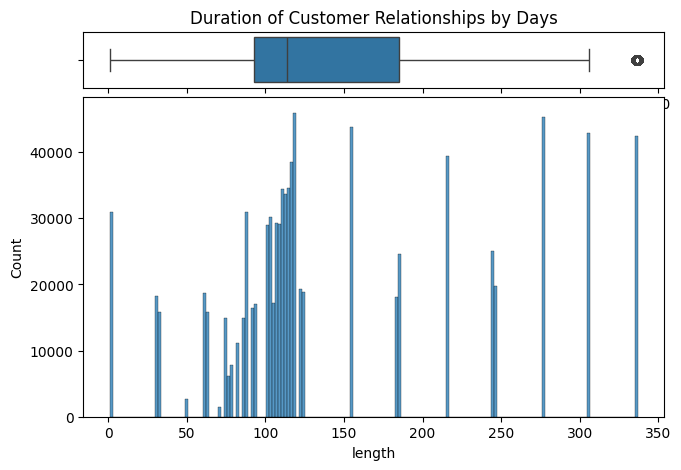

0.00      1.0
0.25     93.0
0.50    114.0
0.75    185.0
1.00    337.0
Name: length, dtype: float64

In [28]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2, 
                            ncols=1, 
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=df_customer, x='length', ax=ax_top)
sns.histplot(data=df_customer, x='length', ax=ax_bot)

ax_top.set(
    title='Duration of Customer Relationships by Days'
)

plt.show()
display(df_customer['length'].quantile([0, 0.25, 0.5, 0.75, 1]))

Pikirin cui

Berdasarkan distribusi di atas, kita akan kelompokkan customer berdasarkan length-nya ke dalam 4 kelompok yaitu :
- 4 (Veteran) : telah bergabung lebih dari 185 hari
- 3 (Established) : telah bergabung antara 114 hingga 185 hari terakhir
- 2 (Acquainted) : telah bergabung antara 93 hingga 113 hari terakhir
- 1 (Newcomer) : baru bergabung antara 1 hingga 92 hari terakhir

In [29]:
df_customer['l_score'] = pd.qcut(
    df_customer['length'],              # data
    q=4,                                # dibagi menjadi 4 kelompok sama banyak
    labels=[1, 2, 3, 4]                 # pelabelan, untuk length: semakin lama, maka semakin besar skornya
).astype(int)

df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score
CustomerID,,,,,
C3137784,336,336,1,271.44,4
C8026573,88,88,1,649.00,1
C3514350,113,113,1,114.00,2
C2064458,123,123,1,296.00,3
C7626213,102,102,1,397.00,2


**Recency Segmentation**

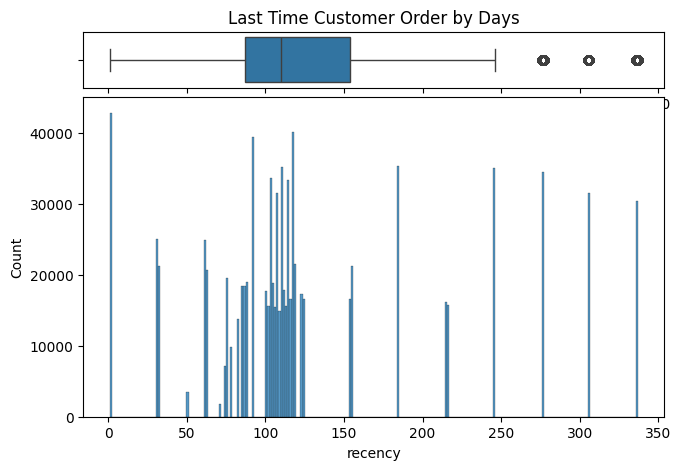

0.00      1.0
0.25     87.0
0.50    110.0
0.75    154.0
1.00    337.0
Name: recency, dtype: float64

In [30]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2, 
                            ncols=1, 
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=df_customer, x='recency', ax=ax_top)
sns.histplot(data=df_customer, x='recency', ax=ax_bot)

ax_top.set(
    title='Last Time Customer Order by Days'
)

plt.show()
display(df_customer['recency'].quantile([0, 0.25, 0.5, 0.75, 1]))

Berdasarkan distribusi di atas, kita akan kelompokkan customer berdasarkan recency-nya ke dalam 4 kelompok yaitu :
- 4 (Active) : melakukan transaksi kurang dari 87 hari terakhir
- 3 (Warm) : melakukan transaksi antara 87 hingga 109 hari terakhir
- 2 (Cold) : melakukan transaksi antara 110 hingga 154 hari terakhir
- 1 (Inactive) : melakukan transaksi lebih dari 154 hari terakhir

In [31]:
df_customer['r_score'] = pd.qcut(
    df_customer['recency'],             # data
    q=4,                                # dibagi menjadi 4 kelompok sama banyak
    labels=[4, 3, 2, 1]                 # pelabelan, untuk recency: semakin kecil, maka semakin besar skornya
).astype(int)

df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score
CustomerID,,,,,,
C3137784,336,336,1,271.44,4,1
C8026573,88,88,1,649.00,1,3
C3514350,113,113,1,114.00,2,2
C2064458,123,123,1,296.00,3,2
C7626213,102,102,1,397.00,2,3


**Frequency Segmentation**

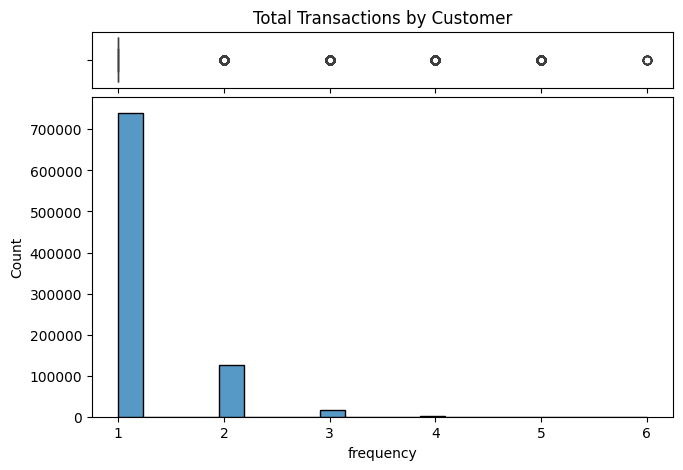

0.00    1.0
0.25    1.0
0.50    1.0
0.75    1.0
1.00    6.0
Name: frequency, dtype: float64

In [32]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2, 
                            ncols=1, 
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=df_customer, x='frequency', ax=ax_top)
sns.histplot(data=df_customer, x='frequency', ax=ax_bot)

ax_top.set(
    title='Total Transactions by Customer'
)

plt.show()
display(df_customer['frequency'].quantile([0, 0.25, 0.5, 0.75, 1]))

Berdasarkan distribusi di atas, kita akan kelompokkan customer berdasarkan frequency-nya ke dalam 4 kelompok mengacu pada jumlah transaksi yang kita tentukan yaitu:
- 4 (Loyal) : melakukan transaki sebanyak 5 atau 6 kali
- 3 (High) : melakukan transaksi 4 hingga 3 kali
- 2 (Medium) : melakukan transaksi 2 kali
- 1 (Low) : melakukan transaksi hanya 1 kali.

In [33]:
def f_score(x):
    if x==1:
        return 1
    elif x == 2:
        return 2
    elif x <= 4:
        return 3
    else:
        return 4
    
df_customer['f_score'] = df_customer['frequency'].apply(f_score)
df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score,f_score
CustomerID,,,,,,,
C3137784,336,336,1,271.44,4,1,1
C8026573,88,88,1,649.00,1,3,1
C3514350,113,113,1,114.00,2,2,1
C2064458,123,123,1,296.00,3,2,1
C7626213,102,102,1,397.00,2,3,1


**Monetary Segmentation**

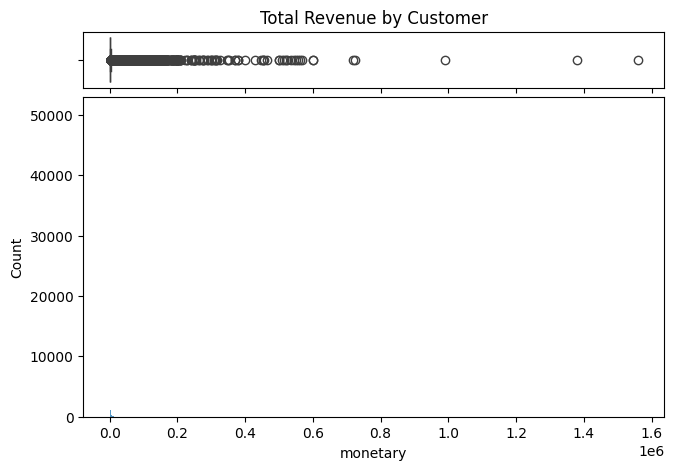

0.00          0.00
0.25        200.00
0.50        536.80
0.75       1500.00
1.00    1560034.99
Name: monetary, dtype: float64

In [34]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2, 
                            ncols=1, 
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=df_customer, x='monetary', ax=ax_top)
sns.histplot(data=df_customer, x='monetary', ax=ax_bot)

ax_top.set(
    title='Total Revenue by Customer'
)

plt.show()
display(df_customer['monetary'].quantile([0, 0.25, 0.5, 0.75, 1]))

Berdasarkan distribusi di atas, kita akan kelompokkan customer berdasarkan monetary-nya ke dalam 4 kelompok yaitu :
- 4 (Top Spender) : melakukan transaksi lebih dari 1.500 dollar
- 3 (High Spender) : melakukan transaksi antara 536 hingga 1500 dollar
- 2 (Medium Spender) : melakukan transaksi antara 200 hingga 535 dollar
- 1 (Low Spender) : melakukan transaksi kurang dari dari 200 dollar

In [35]:
df_customer['m_score'] = pd.qcut(
    df_customer['monetary'],            # data
    q=4,                                # dibagi menjadi 4 kelompok sama banyak
    labels=[1, 2, 3, 4]                 # pelabelan, untuk monetary: semakin besar, maka semakin besar skornya
).astype(int)

df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score,f_score,m_score
CustomerID,,,,,,,,
C3137784,336,336,1,271.44,4,1,1,2
C8026573,88,88,1,649.00,1,3,1,3
C3514350,113,113,1,114.00,2,2,1,1
C2064458,123,123,1,296.00,3,2,1,2
C7626213,102,102,1,397.00,2,3,1,2


### `3. Labelling Segment`

Selanjutnya kita akan melakukan customer segmentation dengan metode Combining Individual Scores Approach


Pada tahapan ini kita akan menggabungkan l_score, r_score, f_score, dan m_score menjadi lrfm_score_combined

In [36]:
df_customer['lrfm_score_combined'] = df_customer['l_score'].astype(str) + df_customer['r_score'].astype(str) + df_customer['f_score'].astype(str) + df_customer['m_score'].astype(str)
df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score,f_score,m_score,lrfm_score_combined
CustomerID,,,,,,,,,
C3137784,336,336,1,271.44,4,1,1,2,4112
C8026573,88,88,1,649.00,1,3,1,3,1313
C3514350,113,113,1,114.00,2,2,1,1,2211
C2064458,123,123,1,296.00,3,2,1,2,3212
C7626213,102,102,1,397.00,2,3,1,2,2312


In [37]:
seg_map = {
    r'[1-2][1-4][1-4][1-2]': 'New Cust Low Value', # pelanggan baru dengan jumlah transaksi kecil
    r'[1-2][1-4][1-4][3-4]': 'New Cust High Value', # pelanggan baru dengan jumlah transaksi besar
    r'[3-4][1-2][1-4][1-4]': 'Old Cust Inactive', # pelanggan lama yang sudah lama tidak melakukan transaksi
    r'[3-4][1-2][3-4][3-4]': 'Need Attention', # pelanggan lama yang sudah lama tidak melakukan transaksi tetapi jumlah transaksi dan frekuensinya besar
    r'[3-4][3-4][3-4][3-4]': 'Loyal Cust', # pelanggan lama yang baru melakukan transaksi, sering melakukan transaksi dengan jumlah transaksi besar
    r'[3-4][3-4][3-4][1-2]': 'Potensial Loyal Cust', # pelanggan lama yang baru melakukan transaksi, sering melakukan transaksi dengan jumlah transaksi kecil
    r'[3-4][3-4][1-2][1-4]': 'Reactivated Old Cust' # pelanggan lama yang baru melakukan transaksi
}
    
df_customer['lrfm_segment_combined'] = df_customer['lrfm_score_combined'].replace(seg_map, regex=True)
df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score,f_score,m_score,lrfm_score_combined,lrfm_segment_combined
CustomerID,,,,,,,,,,
C3137784,336,336,1,271.44,4,1,1,2,4112,Old Cust Inactive
C8026573,88,88,1,649.00,1,3,1,3,1313,New Cust High Value
C3514350,113,113,1,114.00,2,2,1,1,2211,New Cust Low Value
C2064458,123,123,1,296.00,3,2,1,2,3212,Old Cust Inactive
C7626213,102,102,1,397.00,2,3,1,2,2312,New Cust Low Value


Kita akan coba tampilkan karakteristik dari setiap segment dalam bentuk visualisasi sebagai berikut:

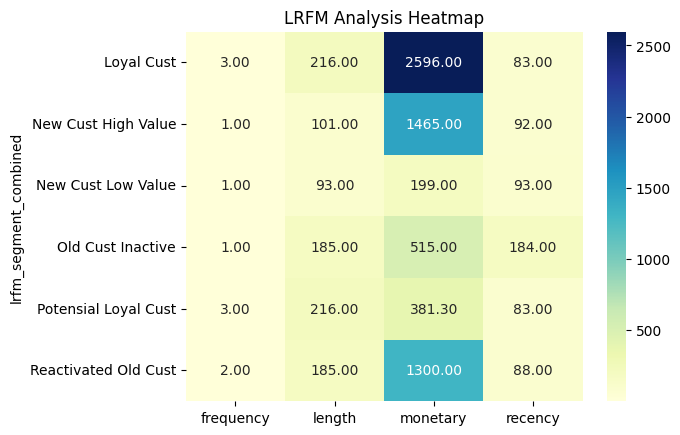

In [38]:
lrfm_heatmap = df_customer.pivot_table(index='lrfm_segment_combined', values=['length', 'recency', 'frequency', 'monetary'], aggfunc='median')

# Create the heatmap
sns.heatmap(lrfm_heatmap, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title('LRFM Analysis Heatmap')
plt.show()